1. What is unsupervised learning in the context of machine learning?
  - A type of machine learning where:
     - No labeled output is provided
     - Model learns hidden patterns from data
  - Main goal:
     - Discover structure (groups, relationships, patterns)
  - Common tasks:
     - Clustering (K-Means, DBSCAN)
     - Dimensionality reduction (PCA)
  - Real-life example:
    - Grouping customers based on buying behavior without knowing categories.

2. How does K-Means clustering algorithm work?
  - Step-by-step:
     - Choose number of clusters (K)
     - Initialize K random centroids
     - Assign each point to nearest centroid (using distance like Euclidean)
     - Recalculate centroids (mean of assigned points)
     - Repeat until centroids stop changing
  - Objective:
     - Minimize within-cluster variance (inertia)
  - Important:
     - Sensitive to initialization
     - Works best for spherical clusters

3. Explain the concept of a dendrogram in hierarchical clustering.
  - Tree-like diagram.
  - Shows how clusters merge step by step.
  - Helps decide number of clusters.
  - Key elements:
     - Leaves → individual data points
     - Branches → cluster merges
     - Height → distance between clusters

4. What is the main difference between K-Means and Hierarchical Clustering?
  - K-Means
       - Needs K beforehand
       - Fast and scalable
       - Produces flat clusters
  - Hierarchical
       - No need to specify K initially
       - Produces hierarchy (tree structure)
       - Computationally expensive
  - Summary:
       - K-Means → efficiency
       - Hierarchical → interpretability

5. What are the advantages of DBSCAN over K-Means?
  - No need to define number of clusters
  - Can detect: Arbitrary shaped clusters (non-spherical)
  - Automatically identifies noise/outliers
  - Works well with real-world uneven data

6. When would you use Silhouette Score in clustering?
  - Used to evaluate clustering quality
  - Helps: Compare clustering algorithms & Choose optimal K.
  -  Interpretation:
       - +1 → well separated clusters
       - 0 → overlapping clusters
       - -1 → wrong clustering

7. What are the limitations of Hierarchical Clustering?
  - Time complexity is high → not good for large datasets
  - Memory intensive
  - No backtracking: Once clusters merge → cannot undo
  - Sensitive to noise and outliers

8. Why is feature scaling important in clustering algorithms like K-Means?
  - Most clustering uses distance (Euclidean)
  - Features with large values dominate
  - Example: Salary vs Age → salary dominates
  - Solution: Standardization (mean = 0, std = 1) & Normalization (0–1 range).

9. How does DBSCAN identify noise points?
  - Based on density:
     - Core points → enough neighbors
     - Border points → near core points
     - Noise → not enough neighbors
  - Noise points:
     - Do not belong to any cluster
     - Marked as outliers

10. Define inertia in the context of K-Means.
  - Mathematical meaning:
      - Sum of squared distances of points to their cluster centroid
  - Interpretation: Lower inertia = tighter clusters
  - But: Always decreases as K increases , So not enough alone.

11. What is the elbow method in K-Means clustering?
  - Steps:
       - Run K-Means for different K values
       - Plot K vs inertia
  - Observation: Sharp decrease → then slows , That “bend” (elbow) is optimal K.
  - Why it works: After certain K, improvement becomes minimal.
    
12. Describe the concept of "density" in DBSCAN.
  - Density = number of points within a radius (ε)
  - Types: Dense region → cluster & Sparse region → noise
  - Idea: Clusters are areas of high density separated by low density

13. Can hierarchical clustering be used on categorical data?
  - Yes, but Cannot use Euclidean distance
  - Use CASE: Hamming distance, Jaccard similarity
  - Works well for: Text data & Survey responses

14. What does a negative Silhouette Score indicate?
  - Meaning: Data point is closer to another cluster than its own
  - Indicates: Poor clustering , Overlapping clusters & Wrong K

15. Explain the term "linkage criteria" in hierarchical clustering.
  - Defines how distance between clusters is calculated
  - Types:
     - Single linkage → nearest points
     - Complete linkage → farthest points
     - Average linkage → average distance
     - Ward’s method → minimize variance
  - Impact: Changes cluster shape and structure

16. Why might K-Means clustering perform poorly on data with varying cluster sizes or densities?
  - Assumes: Equal-sized clusters , Similar density
  - Cannot detect:
      - Irregular shapes
      - Different densities
  - Result: Misclassification of points

17. What are the core parameters in DBSCAN, and how do they influence clustering?
  - ε (epsilon): Radius of neighborhood
  - MinPts: Minimum points needed to form cluster
  - Effect: Small ε → more noise , Large ε → clusters merge & High MinPts → stricter clustering. 

 18. How does K-Means++ improve upon standard K-Means initialization?
  - Instead of random initialization: Chooses centroids far apart
  - Benefits: Better clustering quality , Faster convergence & Reduces chances of local minima.

19. What is agglomerative clustering?
  - Bottom-up approach:
      - Start with each point as separate cluster
      - Merge closest clusters step-by-step
  - Stops when: One cluster remains OR desired clusters formed

20. What makes Silhouette Score a better metric than just inertia for model evaluation?
  - Inertia - Only measures compactness
  - Silhouette Score Measures:
     - Cohesion (within cluster)
     - Separation (between clusters)
  - Conclusion: Gives more realistic evaluation of clustering quality

Practical Q & A :

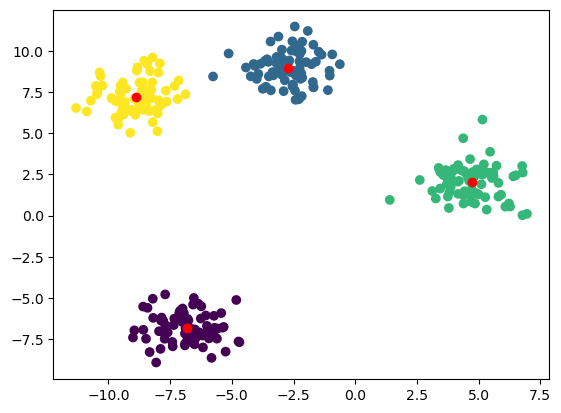

In [2]:
# 21.Generate synthetic data with 4 centers using make_blobs and apply K-Means clustering. Visualize using a scatter plot.
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")

# Generate data
X, y = make_blobs(n_samples=300, centers=4, random_state=42)

# Apply K-Means
kmeans = KMeans(n_clusters=4)
labels = kmeans.fit_predict(X)

# Plot
plt.scatter(X[:,0], X[:,1], c=labels)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], color='red')
plt.show()

In [3]:
# 22.Load the Iris dataset and use Agglomerative Clustering to group the data into 3 clusters. Display the first 10 predicted labels.
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

X = load_iris().data

model = AgglomerativeClustering(n_clusters=3)
labels = model.fit_predict(X)

print(labels[:10])

[1 1 1 1 1 1 1 1 1 1]


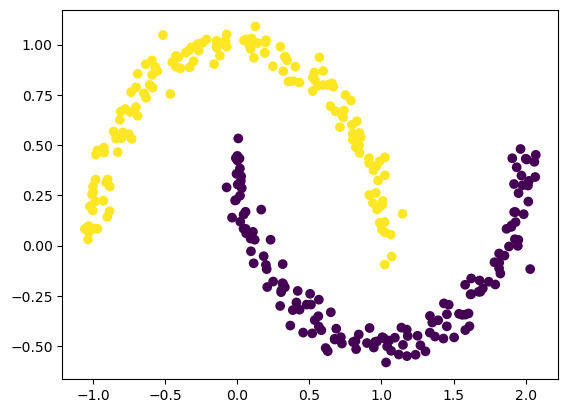

In [4]:
# 23. Generate synthetic data using make_moons and apply DBSCAN. Highlight outliers in the plot.
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X, _ = make_moons(n_samples=300, noise=0.05)

db = DBSCAN(eps=0.2, min_samples=5)
labels = db.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

In [5]:
# 24. Load the Wine dataset and apply K-Means clustering after standardizing the features. Print the size of each cluster.
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

X = load_wine().data
X = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X)

print(np.bincount(labels))  # cluster sizes

[51 66 61]


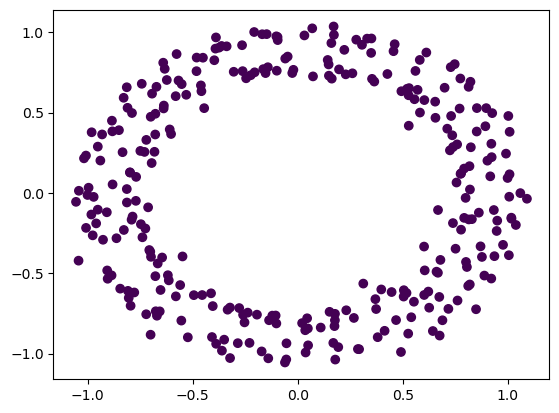

In [6]:
# 25. Use make_circles to generate synthetic data and cluster it using DBSCAN. Plot the result
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X, _ = make_circles(n_samples=300, noise=0.05)

labels = DBSCAN(eps=0.2).fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

In [7]:
# 26. Load the Breast Cancer dataset, apply MinMaxScaler, and use K-Means with 2 clusters. Output the cluster centroids
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

X = load_breast_cancer().data
X = MinMaxScaler().fit_transform(X)

kmeans = KMeans(n_clusters=2)
kmeans.fit(X)

print(kmeans.cluster_centers_)

[[0.50483563 0.39560329 0.50578661 0.36376576 0.46988732 0.42226302
  0.41838662 0.46928035 0.45899738 0.29945886 0.19093085 0.19112073
  0.17903433 0.13086432 0.18017962 0.25890126 0.12542475 0.30942779
  0.190072   0.13266975 0.48047448 0.45107371 0.4655302  0.31460597
  0.49868817 0.36391461 0.39027292 0.65827197 0.33752296 0.26041387]
 [0.25535358 0.28833455 0.24696416 0.14388369 0.35743076 0.18019471
  0.10344776 0.1306603  0.34011829 0.25591606 0.06427485 0.18843043
  0.05975663 0.02870108 0.18158628 0.13242941 0.05821528 0.18069336
  0.17221057 0.08403996 0.2052406  0.32069002 0.19242138 0.09943446
  0.3571115  0.14873935 0.13142287 0.26231363 0.22639412 0.15437354]]


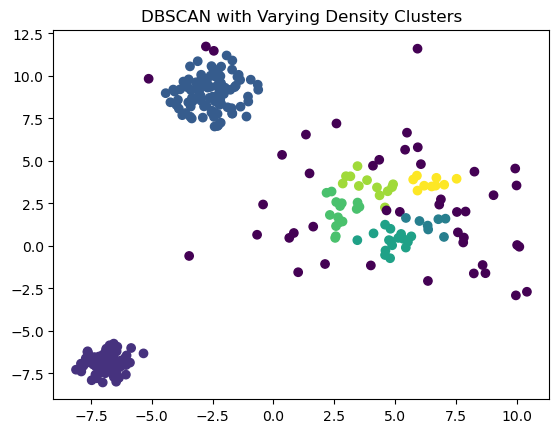

In [8]:
# 27. Generate synthetic data using make_blobs with varying cluster standard deviations and cluster with DBSCAN.
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Generate data with different cluster spreads
X, _ = make_blobs(n_samples=300, centers=3, 
                  cluster_std=[1.0, 2.5, 0.5], 
                  random_state=42)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5)
labels = dbscan.fit_predict(X)

# Plot
plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("DBSCAN with Varying Density Clusters")
plt.show()

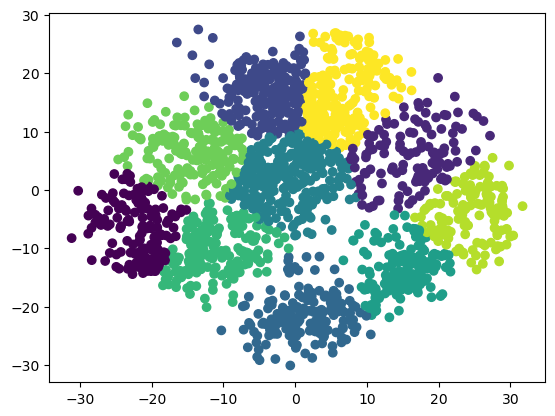

In [9]:
# 28. Load the Digits dataset, reduce it to 2D using PCA, and visualize clusters from K-Means
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = load_digits().data

X_pca = PCA(n_components=2).fit_transform(X)

labels = KMeans(n_clusters=10).fit_predict(X_pca)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.show()

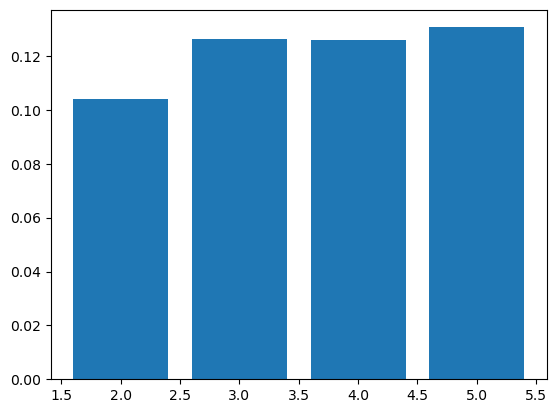

In [10]:
# 29. Create synthetic data using make_blobs and evaluate silhouette scores for k = 2 to 5. Display as a bar chart
from sklearn.metrics import silhouette_score

scores = []
for k in range(2,6):
    labels = KMeans(n_clusters=k).fit_predict(X)
    scores.append(silhouette_score(X, labels))

plt.bar(range(2,6), scores)
plt.show()

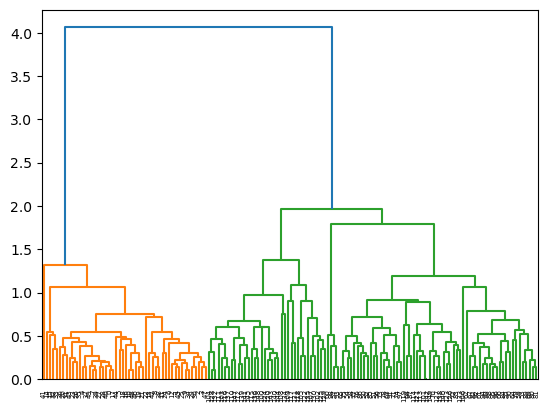

In [11]:
# 30. Load the Iris dataset and use hierarchical clustering to group data. Plot a dendrogram with average linkage
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

X = load_iris().data

Z = linkage(X, method='average')

dendrogram(Z)
plt.show()

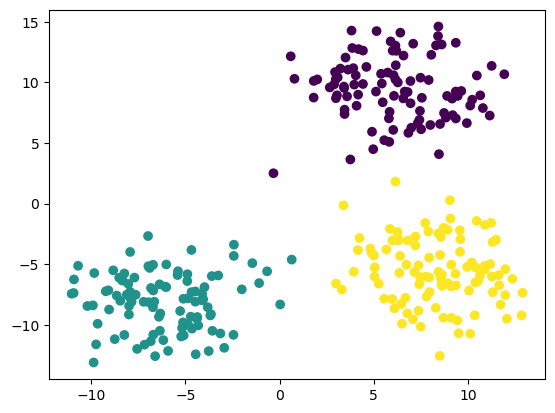

In [12]:
# 31. Generate synthetic data with overlapping clusters using make_blobs, then apply K-Means and visualize with decision boundaries.
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=2.5)

labels = KMeans(n_clusters=3).fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

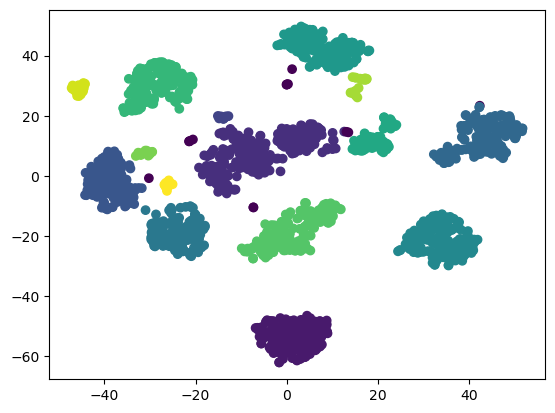

In [13]:
# 32. Load the Digits dataset and apply DBSCAN after reducing dimensions with t-SNE. Visualize the results.
from sklearn.manifold import TSNE

X = load_digits().data
X_tsne = TSNE(n_components=2).fit_transform(X)

labels = DBSCAN(eps=3).fit_predict(X_tsne)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels)
plt.show()

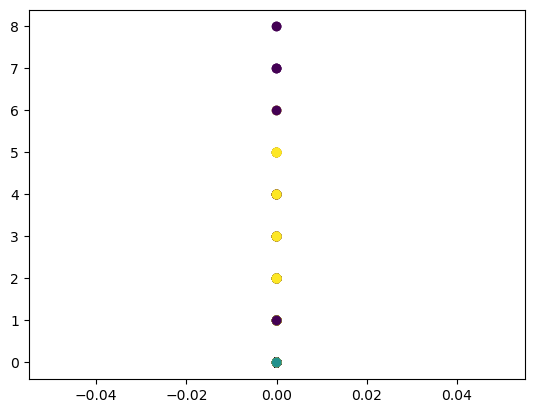

In [14]:
# 33. Generate synthetic data using make_blobs and apply Agglomerative Clustering with complete linkage. Plot the result.
labels = AgglomerativeClustering(n_clusters=3, linkage='complete').fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

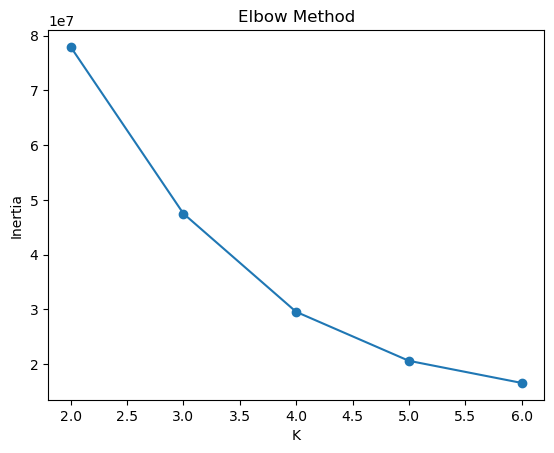

In [15]:
# 34. Load the Breast Cancer dataset and compare inertia values for K = 2 to 6 using K-Means. Show results in a line plot.
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load dataset
X = load_breast_cancer().data

inertia = []

for k in range(2,7):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

# Plot
plt.plot(range(2,7), inertia, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

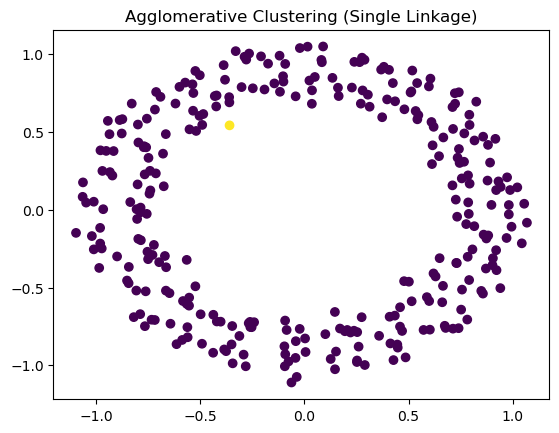

In [16]:
# 35. Generate synthetic concentric circles using make_circles and cluster using Agglomerative Clustering with single linkage.
from sklearn.datasets import make_circles
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, _ = make_circles(n_samples=300, noise=0.05, random_state=42)

labels = AgglomerativeClustering(n_clusters=2, linkage='single').fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("Agglomerative Clustering (Single Linkage)")
plt.show()

In [17]:
# 36. Use the Wine dataset, apply DBSCAN after scaling the data, and count the number of clusters (excluding noise).
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

X = load_wine().data
X = StandardScaler().fit_transform(X)

labels = DBSCAN(eps=1.5, min_samples=5).fit_predict(X)

# Count clusters (excluding noise)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print("Number of clusters:", n_clusters)

Number of clusters: 0


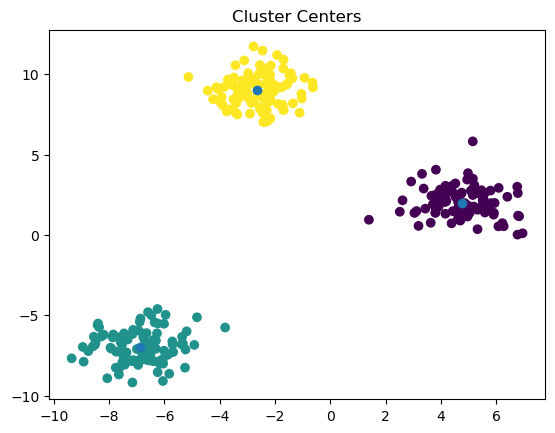

In [18]:
# 37. Generate synthetic data with make_blobs and apply KMeans. Then plot the cluster centers on top of the data points.
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=3, random_state=42)

kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1])
plt.title("Cluster Centers")
plt.show()

In [19]:
# 38. Load the Iris dataset, cluster with DBSCAN, and print how many samples were identified as noise
from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN

X = load_iris().data

labels = DBSCAN(eps=0.5, min_samples=5).fit_predict(X)

noise_count = list(labels).count(-1)

print("Noise points:", noise_count)

Noise points: 17


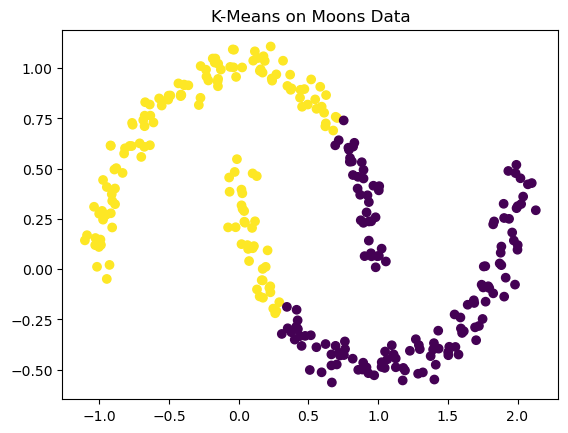

In [20]:
# 39. Generate synthetic non-linearly separable data using make_moons, apply K-Means, and visualize the clustering result.
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

labels = KMeans(n_clusters=2).fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("K-Means on Moons Data")
plt.show()

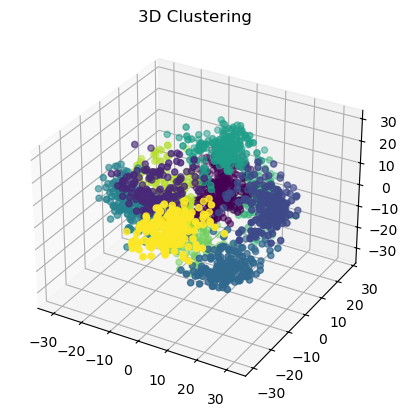

In [21]:
# 40. Load the Digits dataset, apply PCA to reduce to 3 components, then use KMeans and visualize with a 3D scatter plot.
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = load_digits().data

# Reduce to 3D
X_pca = PCA(n_components=3).fit_transform(X)

labels = KMeans(n_clusters=10).fit_predict(X_pca)

# 3D Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels)

plt.title("3D Clustering")
plt.show()

In [22]:
# 41.Generate synthetic blobs with 5 centers and apply KMeans. Then use silhouette_score to evaluate the clustering.
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Generate data
X, _ = make_blobs(n_samples=300, centers=5, random_state=42)

# Apply KMeans
kmeans = KMeans(n_clusters=5)
labels = kmeans.fit_predict(X)

# Evaluate
score = silhouette_score(X, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.6586478247336219


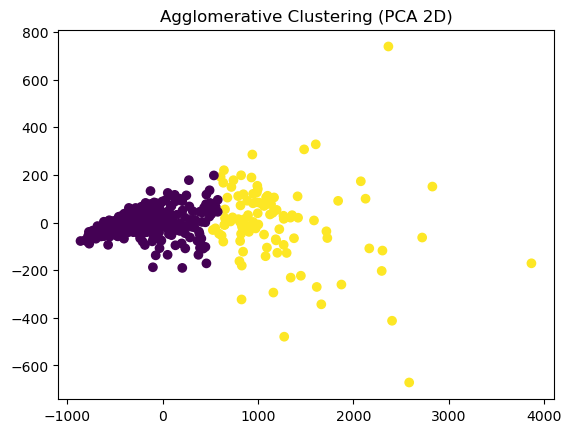

In [23]:
# 42. Load the Breast Cancer dataset, reduce dimensionality using PCA, and apply Agglomerative Clustering. Visualize in 2D.
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X = load_breast_cancer().data

# Reduce to 2D
X_pca = PCA(n_components=2).fit_transform(X)
# PCA reduces dimensions so we can visualize clusters easily.

# Clustering
labels = AgglomerativeClustering(n_clusters=2).fit_predict(X_pca)

# Plot
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title("Agglomerative Clustering (PCA 2D)")
plt.show()

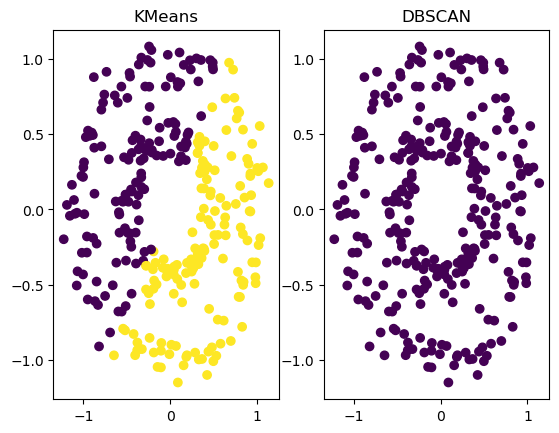

In [24]:
# 43. Generate noisy circular data using make_circles and visualize clustering results from KMeans and DBSCAN side-by-side.
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt

X, _ = make_circles(n_samples=300, noise=0.1, factor=0.5)

kmeans_labels = KMeans(n_clusters=2).fit_predict(X)
dbscan_labels = DBSCAN(eps=0.2).fit_predict(X)

# Side-by-side plot
plt.subplot(1,2,1)
plt.scatter(X[:,0], X[:,1], c=kmeans_labels)
plt.title("KMeans")

plt.subplot(1,2,2)
plt.scatter(X[:,0], X[:,1], c=dbscan_labels)
plt.title("DBSCAN")

plt.show()
# KMeans fails for circular shapes, DBSCAN works better.

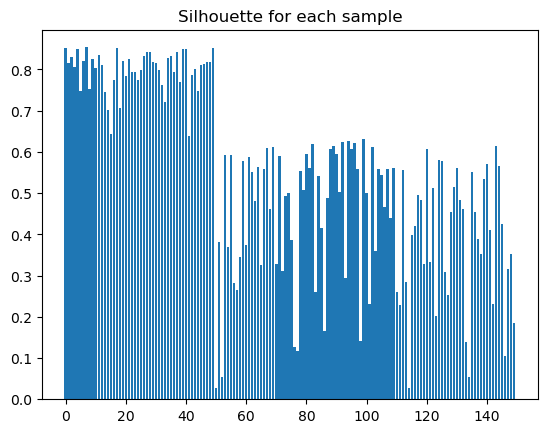

In [25]:
# 44. Load the Iris dataset and plot the Silhouette Coefficient for each sample after KMeans clustering.

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt

X = load_iris().data

labels = KMeans(n_clusters=3).fit_predict(X)

sil_samples = silhouette_samples(X, labels)

plt.bar(range(len(sil_samples)), sil_samples)
plt.title("Silhouette for each sample")
plt.show()

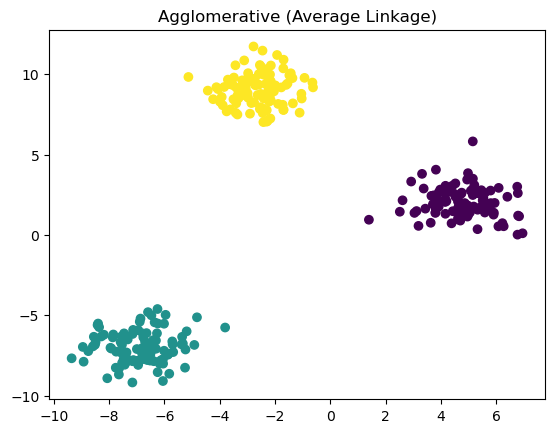

In [26]:
# 45. Generate synthetic data using make_blobs and apply Agglomerative Clustering with 'average' linkage. Visualize clusters.
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=3, random_state=42)

labels = AgglomerativeClustering(n_clusters=3, linkage='average').fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("Agglomerative (Average Linkage)")
plt.show()

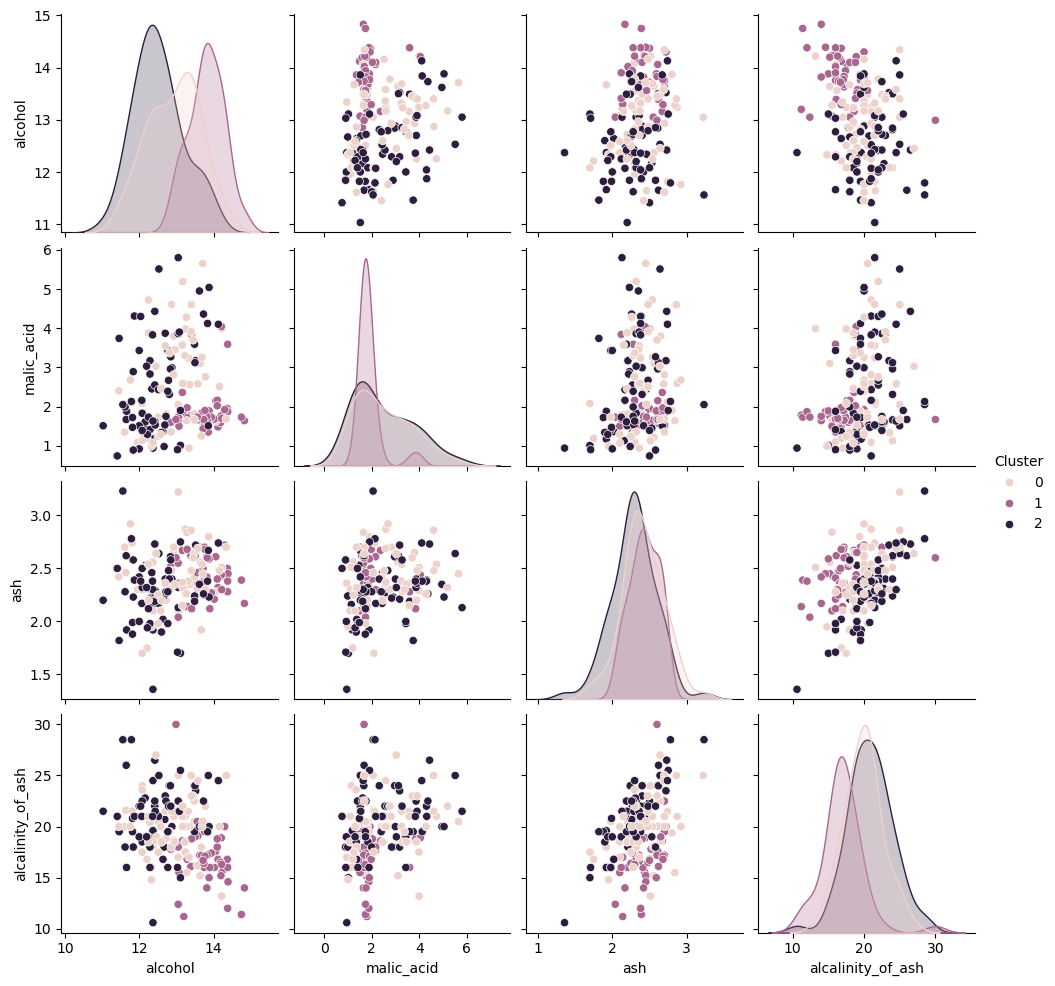

In [27]:
# 46. Load the Wine dataset, apply KMeans, and visualize the cluster assignments in a seaborn pairplot (first 4 features).
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans

wine = load_wine()
X = wine.data

kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X)

# DataFrame for seaborn
df = pd.DataFrame(X[:, :4], columns=wine.feature_names[:4])
df['Cluster'] = labels


# Pairplot helps visualize clusters across multiple features.
sns.pairplot(df, hue='Cluster')

In [28]:
# 47. Generate noisy blobs using make_blobs and use DBSCAN to identify both clusters and noise points. Print the count.
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN

X, _ = make_blobs(n_samples=300, centers=3, cluster_std=2.0)

labels = DBSCAN(eps=0.8).fit_predict(X)

# Count clusters
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise = list(labels).count(-1)

# DBSCAN detects both clusters and noise automatically.
print("Clusters:", n_clusters)
print("Noise points:", noise)

Clusters: 5
Noise points: 93


In [ ]:
# 48. Load the Digits dataset, reduce dimensions using t-SNE, then apply Agglomerative Clustering and plot the clusters.
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X = load_digits().data

# Reduce to 2D using t-SNE
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X)

labels = AgglomerativeClustering(n_clusters=10).fit_predict(X_tsne)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels)
plt.title("t-SNE + Agglomerative")
plt.show()
# t-SNE helps visualize high-dimensional data like digits.